# Tema 3 - Attention & MLP
> Implementati  mecanismul Attention si perceptroni multistrat (MLP blocks).
>
> ---
> Implement Attention-mecanism and Multi-layer Perceptron.

To do so, in an illustrative way, we are going to build a mini-Transformer because it uses both a Multi-Head Self-Attention (Attention Mecanism) and a Multi-Layer Perceptron.

---
---

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import itertools
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)


Device : cpu


In [ ]:
# ------------------------------------------------------------
# 1. IDENTITY / SUBJECT-VERB AGREEMENT
# ------------------------------------------------------------

identity_sentences = [
    "i am a teacher",
    "i am a doctor",
    "i am an engineer",
    "i am a nurse",
    "i am a pilot",
    "i am an artist",
    "i am a scientist",
    "i am a writer",

    "you are a teacher",
    "you are a doctor",
    "you are an engineer",
    "you are a nurse",
    "you are a pilot",
    "you are an artist",
    "you are a scientist",
    "you are a writer",

    "he is a teacher",
    "he is a doctor",
    "he is an engineer",
    "he is a nurse",
    "he is a pilot",
    "he is an artist",
    "he is a scientist",
    "he is a writer",

    "she is a teacher",
    "she is a doctor",
    "she is an engineer",
    "she is a nurse",
    "she is a pilot",
    "she is an artist",
    "she is a scientist",
    "she is a writer",

    "we are teachers",
    "we are doctors",
    "we are engineers",
    "we are nurses",
    "we are pilots",
    "we are artists",
    "we are scientists",
    "we are writers",

    "they are teachers",
    "they are doctors",
    "they are engineers",
    "they are nurses",
    "they are pilots",
    "they are artists",
    "they are scientists",
    "they are writers",
]


# ------------------------------------------------------------
# 2. ACTIONS
# ------------------------------------------------------------

action_sentences = [
    "i eat an apple",
    "i eat a banana",
    "i eat an orange",
    "i eat some bread",
    "i eat some rice",
    "i eat a sandwich",
    "i eat some soup",
    "i eat a mango",

    "you eat an apple",
    "you eat a banana",
    "you eat an orange",
    "you eat some bread",
    "you eat some rice",
    "you eat a sandwich",
    "you eat some soup",
    "you eat a mango",

    "he eats an apple",
    "he eats a banana",
    "he eats an orange",
    "he eats some bread",
    "he eats some rice",
    "he eats a sandwich",
    "he eats some soup",
    "he eats a mango",

    "she eats an apple",
    "she eats a banana",
    "she eats an orange",
    "she eats some bread",
    "she eats some rice",
    "she eats a sandwich",
    "she eats some soup",
    "she eats a mango",

    "we eat an apple",
    "we eat a banana",
    "we eat an orange",
    "we eat some bread",
    "we eat some rice",
    "we eat a sandwich",
    "we eat some soup",
    "we eat a mango",

    "they eat an apple",
    "they eat a banana",
    "they eat an orange",
    "they eat some bread",
    "they eat some rice",
    "they eat a sandwich",
    "they eat some soup",
    "they eat a mango",

    "the boy reads a book",
    "the girl reads a book",
    "the teacher reads a letter",
    "the doctor reads a report",
    "the student writes a letter",
    "the artist paints a picture",
    "the chef cooks a meal",
    "the farmer grows vegetables",

    "the boy opens the door",
    "the girl closes the window",
    "the teacher carries a bag",
    "the doctor checks the patient",
    "the student carries a book",
    "the artist draws a house",
    "the chef cuts the bread",
    "the farmer feeds the animals",

    "the dog chases the ball",
    "the cat catches the mouse",
    "the bird watches the tree",
    "the child throws the ball",
    "the woman carries the basket",
    "the man opens the box",
    "the boy kicks the ball",
    "the girl holds the flower",
]


# ------------------------------------------------------------
# 3. ADJECTIVE + NOUN RELATIONSHIPS
# ------------------------------------------------------------

description_sentences = [
    "the red car moves quickly",
    "the blue car waits outside",
    "the old car needs repairs",
    "the small car fits inside",
    "the fast car passes the truck",

    "the red bird flies above the house",
    "the blue bird sits in the tree",
    "the small bird eats seeds",
    "the young bird follows its mother",
    "the quiet bird rests on a branch",

    "the black dog runs across the garden",
    "the brown dog sleeps near the door",
    "the small dog follows the boy",
    "the young dog plays with the ball",
    "the old dog walks slowly",

    "the black cat sleeps on the sofa",
    "the white cat watches the bird",
    "the small cat hides under the table",
    "the young cat follows its mother",
    "the quiet cat waits by the window",

    "the large house stands near the river",
    "the old house has a wooden door",
    "the small house sits on the hill",
    "the blue house has a red roof",
    "the quiet house is near the forest",

    "the tall tree grows beside the road",
    "the old tree stands behind the house",
    "the large tree gives shade",
    "the young tree needs more water",
    "the green tree grows near the river",

    "the wooden boat moves across the lake",
    "the small boat waits near the shore",
    "the old boat needs a new engine",
    "the blue boat belongs to the fisherman",
    "the fast boat crosses the river",

    "the happy child plays in the garden",
    "the young child reads a book",
    "the tired child sleeps on the sofa",
    "the quiet child watches the birds",
    "the curious child opens the box",

    "the bright lamp lights the room",
    "the old lamp stands beside the bed",
    "the small lamp sits on the desk",
    "the broken lamp needs a new bulb",
    "the yellow lamp shines through the night",
]


# ------------------------------------------------------------
# 4. LOCATION / SPATIAL RELATIONSHIPS
# ------------------------------------------------------------

location_sentences = [
    "the book is on the table",
    "the book is under the chair",
    "the book is in the drawer",
    "the book is next to the window",
    "the book is behind the door",

    "the cat is on the sofa",
    "the cat is under the table",
    "the cat is near the window",
    "the cat is behind the chair",
    "the cat is beside the bed",

    "the dog is in the garden",
    "the dog is near the house",
    "the dog is behind the gate",
    "the dog is beside the tree",
    "the dog is under the bridge",

    "the keys are on the table",
    "the keys are in the drawer",
    "the keys are beside the phone",
    "the keys are under the book",
    "the keys are near the door",

    "the phone is on the desk",
    "the phone is beside the computer",
    "the phone is in the bag",
    "the phone is under the book",
    "the phone is near the window",

    "the lamp is beside the bed",
    "the lamp is on the desk",
    "the lamp is near the sofa",
    "the lamp is next to the window",
    "the lamp is behind the chair",

    "the bicycle is outside the house",
    "the bicycle is beside the car",
    "the bicycle is near the garage",
    "the bicycle is behind the gate",
    "the bicycle is next to the wall",

    "the boat is on the lake",
    "the boat is near the shore",
    "the boat is beside the island",
    "the boat is behind the rocks",
    "the boat is under the bridge",
]


# ------------------------------------------------------------
# 5. NEGATION
# ------------------------------------------------------------

negation_sentences = [
    "the dog does not like the rain",
    "the dog does not like loud noises",
    "the dog does not eat vegetables",
    "the dog does not like cold weather",

    "the cat does not like the rain",
    "the cat does not like loud noises",
    "the cat does not eat vegetables",
    "the cat does not like cold weather",

    "the boy does not like the dark",
    "the boy does not eat fish",
    "the boy does not want the toy",
    "the boy does not know the answer",

    "the girl does not like the dark",
    "the girl does not eat fish",
    "the girl does not want the toy",
    "the girl does not know the answer",

    "she does not like the cold",
    "she does not want the blue dress",
    "she does not eat meat",
    "she does not know the man",

    "he does not like the noise",
    "he does not want the old car",
    "he does not eat meat",
    "he does not know the answer",

    "they do not like the rain",
    "they do not want the old house",
    "they do not eat fish",
    "they do not know the teacher",

    "we do not like the weather",
    "we do not want the small room",
    "we do not eat meat",
    "we do not know the answer",
]


# ------------------------------------------------------------
# 6. COREFERENCE
#
# These are deliberately longer because we want the model to
# potentially learn relationships between a pronoun and a noun
# several tokens earlier.
# ------------------------------------------------------------

coreference_sentences = [
    "the dog is hungry so it eats quickly",
    "the dog is thirsty so it drinks water",
    "the dog is tired so it sleeps outside",
    "the dog is scared so it runs away",
    "the dog is happy so it plays outside",

    "the cat is hungry so it eats quickly",
    "the cat is thirsty so it drinks water",
    "the cat is tired so it sleeps on the sofa",
    "the cat is scared so it hides under the bed",
    "the cat is happy so it follows the boy",

    "the teacher is tired so she rests",
    "the teacher is hungry so she eats lunch",
    "the teacher is busy so she closes the door",
    "the teacher is happy so she smiles",
    "the teacher is cold so she wears a coat",

    "the doctor is tired so she sits down",
    "the doctor is busy so she reads the report",
    "the doctor is hungry so she eats lunch",
    "the doctor is worried so she calls the nurse",
    "the doctor is happy so she smiles",

    "the boy is happy so he smiles",
    "the boy is tired so he rests",
    "the boy is hungry so he eats an apple",
    "the boy is cold so he wears a coat",
    "the boy is scared so he runs home",

    "the girl is happy so she smiles",
    "the girl is tired so she rests",
    "the girl is hungry so she eats a banana",
    "the girl is cold so she wears a coat",
    "the girl is scared so she runs home",

    "the bird is scared so it flies away",
    "the bird is hungry so it looks for food",
    "the bird is tired so it rests in the tree",
    "the bird is cold so it hides in the nest",
    "the bird is happy so it sings",

    "the farmer is tired so he sits under the tree",
    "the farmer is hungry so he eats lunch",
    "the farmer is busy so he works in the field",
    "the farmer is happy so he smiles",
    "the farmer is cold so he wears a coat",
]


# ------------------------------------------------------------
# 7. SUBJECT / OBJECT REVERSAL
#
# Very useful for attention.
#
# "the dog chases the cat"
# "the cat chases the dog"
#
# Same words, different relationships.
# ------------------------------------------------------------

reversal_sentences = [
    "the dog chases the cat",
    "the cat chases the dog",

    "the dog follows the boy",
    "the boy follows the dog",

    "the girl watches the bird",
    "the bird watches the girl",

    "the teacher helps the student",
    "the student helps the teacher",

    "the doctor helps the nurse",
    "the nurse helps the doctor",

    "the boy sees the girl",
    "the girl sees the boy",

    "the dog likes the cat",
    "the cat likes the dog",

    "the man carries the box",
    "the box carries the man",

    "the child holds the flower",
    "the flower holds the child",

    "the farmer feeds the horse",
    "the horse feeds the farmer",

    "the mother calls the child",
    "the child calls the mother",

    "the teacher follows the student",
    "the student follows the teacher",

    "the bird follows the cat",
    "the cat follows the bird",

    "the boy carries the bag",
    "the girl carries the bag",

    "the girl opens the door",
    "the boy opens the door",
]


# ------------------------------------------------------------
# 8. TEMPORAL CONTEXT
#
# Same action but different temporal context.
# ------------------------------------------------------------

temporal_sentences = [
    "the boy eats breakfast in the morning",
    "the boy reads a book in the afternoon",
    "the boy sleeps at night",

    "the girl eats breakfast in the morning",
    "the girl reads a book in the afternoon",
    "the girl sleeps at night",

    "the teacher works in the morning",
    "the teacher rests in the afternoon",
    "the teacher goes home at night",

    "the doctor works in the morning",
    "the doctor sees patients in the afternoon",
    "the doctor rests at night",

    "the farmer works in the morning",
    "the farmer feeds the animals in the afternoon",
    "the farmer sleeps at night",

    "the dog plays in the morning",
    "the dog sleeps in the afternoon",
    "the dog walks at night",

    "the cat eats in the morning",
    "the cat sleeps in the afternoon",
    "the cat plays at night",

    "the bird sings in the morning",
    "the bird rests in the afternoon",
    "the bird flies at sunset",

    "we eat breakfast in the morning",
    "we study in the afternoon",
    "we sleep at night",

    "they work in the morning",
    "they walk in the afternoon",
    "they return home at night",
]


# ------------------------------------------------------------
# 9. LONGER SENTENCES
#
# These are particularly important.
#
# The model now has to maintain relationships over a larger
# distance instead of solving everything from neighboring tokens.
# ------------------------------------------------------------

long_sentences = [
    "the boy reads a book while the dog sleeps beside him",
    "the girl reads a book while the cat sleeps beside her",
    "the teacher writes a letter while the students listen",
    "the doctor reads the report while the nurse waits",
    "the farmer works in the field while the dog follows him",

    "the boy takes the red ball from the garden",
    "the girl takes the blue book from the table",
    "the teacher takes the old keys from the drawer",
    "the doctor takes the report from the desk",
    "the farmer takes the basket from the house",

    "the dog runs to the garden when the door opens",
    "the cat hides under the bed when the dog enters",
    "the boy smiles when the teacher enters the room",
    "the girl laughs when the dog catches the ball",
    "the bird flies away when the cat comes closer",

    "the boy gives the book to the teacher",
    "the girl gives the flower to her mother",
    "the teacher gives the student a new book",
    "the doctor gives the nurse the report",
    "the farmer gives the dog some food",

    "the boy puts the book on the table",
    "the girl puts the keys in the drawer",
    "the teacher puts the papers on the desk",
    "the doctor puts the bag beside the chair",
    "the farmer puts the food near the animals",

    "the small dog follows the young boy to the house",
    "the young girl carries the heavy bag to the car",
    "the old teacher reads the long letter in the office",
    "the tired doctor walks slowly toward the hospital",
    "the curious child looks inside the wooden box",

    "the red car waits outside the large house",
    "the blue boat moves slowly across the quiet lake",
    "the small bird sits on the old wooden fence",
    "the black cat sleeps beside the warm fireplace",
    "the young dog plays with the yellow ball",
]


# ------------------------------------------------------------
# 10. AMBIGUOUS / POLYSEMOUS WORDS
#
# The same word appears in different contexts.
#
# This is one of the most useful additions for your experiment.
# ------------------------------------------------------------

ambiguous_sentences = [
    # bank
    "the man goes to the bank to get some money",
    "the woman sits on the bank near the river",
    "the bank closes its doors in the evening",
    "the children sit on the river bank",

    # bat
    "the boy hits the ball with a bat",
    "the bat flies through the dark sky",
    "the girl sees a bat inside the cave",

    # watch
    "the boy wears a watch on his wrist",
    "the girl watches the birds in the garden",
    "the teacher watches the students carefully",
    "the old watch sits on the table",

    # light
    "the lamp gives light to the room",
    "the box is light enough to carry",
    "the morning light enters the window",
    "the small bag is very light",

    # right
    "the shop is on the right side of the road",
    "the boy raises his right hand",
    "the teacher gives the student the right answer",
    "the car turns right at the corner",

    # match
    "the team wins the football match",
    "the boy lights a match near the fire",
    "the two colors are a good match",

    # spring
    "the flowers grow in spring",
    "the old spring moves inside the machine",
    "the children play outside in spring",

    # watch as object/action
    "the doctor checks his watch",
    "the girl watches the clock",
    "the teacher watches the door",
    "the old watch belongs to the man",
]


# ------------------------------------------------------------
# 11. SOCIAL / HUMAN SITUATIONS
#
# These give words more realistic contexts instead of only
# simple physical descriptions.
# ------------------------------------------------------------

social_sentences = [
    "the teacher helps the student with the homework",
    "the student asks the teacher a question",
    "the doctor talks to the nurse",
    "the nurse helps the doctor with the patient",
    "the farmer talks to the neighbor",
    "the boy talks to his friend",
    "the girl calls her mother",
    "the mother helps her daughter",
    "the father helps his son",
    "the child asks his mother for water",

    "the boy gives his friend a book",
    "the girl gives her brother an apple",
    "the teacher gives the student a new pencil",
    "the doctor gives the patient some medicine",
    "the mother gives the child a warm coat",

    "the student listens to the teacher",
    "the child listens to his mother",
    "the boy listens to his friend",
    "the nurse listens to the doctor",
    "the farmer listens to the weather report",

    "the teacher asks the student a question",
    "the student asks the teacher for help",
    "the doctor asks the nurse for the report",
    "the child asks the father for a toy",
    "the boy asks his friend about the game",

    "the girl waits for her mother",
    "the boy waits for his father",
    "the student waits for the teacher",
    "the nurse waits for the doctor",
    "the farmer waits for the rain",
]


# ------------------------------------------------------------
# 12. QUESTIONS
#
# Questions create different grammatical structures and force
# the model to pay attention to relationships between words.
# ------------------------------------------------------------

question_sentences = [
    "where is the book",
    "where is the cat",
    "where is the dog",
    "where are the keys",
    "where is the phone",
    "where is the lamp",
    "where is the bicycle",
    "where is the boat",

    "who is the teacher",
    "who is the doctor",
    "who is the pilot",
    "who is the artist",
    "who is the farmer",

    "what does the dog eat",
    "what does the cat want",
    "what does the boy read",
    "what does the girl carry",
    "what does the teacher write",
    "what does the doctor check",

    "who follows the boy",
    "who follows the girl",
    "who helps the teacher",
    "who helps the doctor",
    "who watches the bird",
    "who carries the bag",

    "when does the boy sleep",
    "when does the girl study",
    "when does the farmer work",
    "when does the dog eat",
    "when does the teacher rest",
]


# ------------------------------------------------------------
# 13. CAUSE / CONSEQUENCE
#
# Useful for longer-range semantic relationships.
# ------------------------------------------------------------

cause_sentences = [
    "the boy is hungry so he eats an apple",
    "the girl is hungry so she eats a sandwich",
    "the dog is thirsty so it drinks water",
    "the cat is thirsty so it drinks milk",
    "the farmer is tired so he rests under the tree",

    "the boy is cold so he wears a coat",
    "the girl is cold so she closes the window",
    "the dog is cold so it sleeps inside",
    "the teacher is cold so she turns on the heater",
    "the farmer is cold so he goes inside",

    "the boy is tired so he goes to bed",
    "the girl is tired so she sits on the sofa",
    "the dog is tired so it sleeps near the door",
    "the cat is tired so it sleeps on the bed",
    "the teacher is tired so she goes home",

    "the boy is happy because he found his ball",
    "the girl is happy because she won the game",
    "the teacher is happy because the students learned",
    "the farmer is happy because the rain arrived",
    "the child is happy because his mother came home",

    "the dog runs inside because it is raining",
    "the cat hides because the dog is nearby",
    "the boy stays home because he is sick",
    "the girl wears a coat because it is cold",
    "the farmer waits because the road is wet",
]


# ------------------------------------------------------------
# 14. COMPARISONS
#
# More semantic relationships between nouns/adjectives.
# ------------------------------------------------------------

comparison_sentences = [
    "the red car is faster than the blue car",
    "the blue car is smaller than the red car",
    "the old house is larger than the small house",
    "the small dog is younger than the old dog",
    "the brown cat is quieter than the black cat",

    "the boy is taller than the girl",
    "the girl is younger than the teacher",
    "the teacher is older than the student",
    "the dog is smaller than the horse",
    "the bird is smaller than the dog",

    "the red boat is faster than the old boat",
    "the new phone is lighter than the old phone",
    "the large box is heavier than the small box",
    "the blue bag is bigger than the red bag",
    "the wooden table is longer than the small desk",

    "the summer day is warmer than the winter day",
    "the morning is quieter than the afternoon",
    "the city is larger than the village",
    "the river is longer than the small stream",
    "the mountain is higher than the hill",
]


# ============================================================
# DATASET
# ============================================================

sentences = (
    identity_sentences
    + action_sentences
    + description_sentences
    + location_sentences
    + negation_sentences
    + coreference_sentences
    + reversal_sentences
    + temporal_sentences
    + long_sentences
    + ambiguous_sentences
    + social_sentences
    + question_sentences
    + cause_sentences
    + comparison_sentences
)

sentences = list(dict.fromkeys(sentences))
random.shuffle(sentences)
print("Number of sentences:", len(sentences))
print("\nExample sentences:")
for s in sentences[:20]:
    print(" -", s)
print("\nLongest sentences:")
for s in sorted(sentences, key=lambda x: len(x.split()), reverse=True)[:10]:
    print(" -", s)
print("\nAverage sentence length:",
      round(sum(len(s.split()) for s in sentences) / len(sentences), 2))
print("\nUnique words:",
      len(set(word for sentence in sentences for word in sentence.split())))

Number of sentences: 502

Example sentences:
 - you eat some bread
 - the dog does not eat vegetables
 - the young dog plays with the yellow ball
 - the keys are on the table
 - the girl does not eat fish
 - they eat a sandwich
 - the happy child plays in the garden
 - the boy waits for his father
 - she eats an orange
 - the dog chases the cat
 - the cat is on the sofa
 - the girl watches the clock
 - the small bag is very light
 - the fast boat crosses the river
 - the box carries the man
 - the cat is scared so it hides under the bed
 - the boy carries the bag
 - the teacher is tired so she rests
 - they eat some rice
 - the lamp is beside the bed

Longest sentences:
 - the boy reads a book while the dog sleeps beside him
 - the girl reads a book while the cat sleeps beside her
 - the farmer works in the field while the dog follows him
 - the cat is scared so it hides under the bed
 - the cat hides under the bed when the dog enters
 - the old teacher reads the long letter in the off

In [ ]:
SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]

all_words = []

for sentence in sentences:
    all_words.extend(sentence.split())

vocab_words = sorted(set(all_words))

vocab = SPECIAL_TOKENS + vocab_words

word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

vocab_size = len(vocab)

print("Vocabulary size :", vocab_size)
print()
print(word_to_id)


Vocabulary size : 368

{'<PAD>': 0, '<BOS>': 1, '<EOS>': 2, '<UNK>': 3, 'a': 4, 'about': 5, 'above': 6, 'across': 7, 'afternoon': 8, 'am': 9, 'an': 10, 'animals': 11, 'answer': 12, 'apple': 13, 'are': 14, 'arrived': 15, 'artist': 16, 'artists': 17, 'asks': 18, 'at': 19, 'away': 20, 'bag': 21, 'ball': 22, 'banana': 23, 'bank': 24, 'basket': 25, 'bat': 26, 'because': 27, 'bed': 28, 'behind': 29, 'belongs': 30, 'beside': 31, 'bicycle': 32, 'bigger': 33, 'bird': 34, 'birds': 35, 'black': 36, 'blue': 37, 'boat': 38, 'book': 39, 'box': 40, 'boy': 41, 'branch': 42, 'bread': 43, 'breakfast': 44, 'bridge': 45, 'bright': 46, 'broken': 47, 'brother': 48, 'brown': 49, 'bulb': 50, 'busy': 51, 'by': 52, 'calls': 53, 'came': 54, 'car': 55, 'carefully': 56, 'carries': 57, 'carry': 58, 'cat': 59, 'catches': 60, 'cave': 61, 'chair': 62, 'chases': 63, 'check': 64, 'checks': 65, 'chef': 66, 'child': 67, 'children': 68, 'city': 69, 'clock': 70, 'closer': 71, 'closes': 72, 'coat': 73, 'cold': 74, 'colors': 

In [ ]:
def encode(sentence):
    tokens = ["<BOS>"] + sentence.split() + ["<EOS>"]
    return [word_to_id.get(token, word_to_id["<UNK>"]) for token in tokens]


def decode(ids):
    return [id_to_word[i] for i in ids]


# Exemple
example = "the blue car is very fast"

encoded = encode(example)

print("Sentence:", example)
print("IDs     :", encoded)
print("Tokens  :", decode(encoded))


Sentence: the blue car is very fast
IDs     : [1, 312, 37, 55, 168, 327, 108, 2]
Tokens  : ['<BOS>', 'the', 'blue', 'car', 'is', 'very', 'fast', '<EOS>']


In [ ]:
encoded_sentences = [encode(sentence) for sentence in sentences]

max_len = max(len(x) for x in encoded_sentences)

PAD_ID = word_to_id["<PAD>"]

inputs = []
targets = []

for seq in encoded_sentences:
    input_seq = seq[:-1]
    target_seq = seq[1:]

    # Padding
    input_seq = input_seq + [PAD_ID] * (max_len - 1 - len(input_seq))
    target_seq = target_seq + [PAD_ID] * (max_len - 1 - len(target_seq))

    inputs.append(input_seq)
    targets.append(target_seq)

inputs = torch.tensor(inputs, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

print("Inputs :", inputs.shape)
print("Targets:", targets.shape)


Inputs : torch.Size([502, 12])
Targets: torch.Size([502, 12])


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0, max_len,
            dtype=torch.float
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]


In [ ]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Projections Q, K et V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Projection finale
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):

        batch_size, seq_len, _ = x.shape

        # --------------------------------
        # 1. Calcul de Q, K et V
        # --------------------------------

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # --------------------------------
        # 2. Séparation en plusieurs heads
        # --------------------------------

        Q = Q.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        K = K.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        V = V.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        # Dimensions :
        # Q, K, V = [batch, heads, seq_len, head_dim]

        # --------------------------------
        # 3. Scores QK^T
        # --------------------------------

        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        # --------------------------------
        # 4. Scaling
        # --------------------------------

        scores = scores / math.sqrt(self.head_dim)

        # --------------------------------
        # 5. Masque causal
        # --------------------------------

        if mask is not None:
            scores = scores.masked_fill(
                mask == 0,
                float("-inf")
            )

        # --------------------------------
        # 6. Softmax
        # --------------------------------

        attention_weights = F.softmax(
            scores,
            dim=-1
        )

        # --------------------------------
        # 7. Pondération des Values
        # --------------------------------

        attention_output = torch.matmul(
            attention_weights,
            V
        )

        # --------------------------------
        # 8. Recombinaison des heads
        # --------------------------------

        attention_output = attention_output.transpose(
            1, 2
        ).contiguous()

        attention_output = attention_output.view(
            batch_size,
            seq_len,
            self.d_model
        )

        # --------------------------------
        # 9. Projection finale
        # --------------------------------

        output = self.W_o(attention_output)

        return output, attention_weights


torch.Size([1, 1, 12, 12])


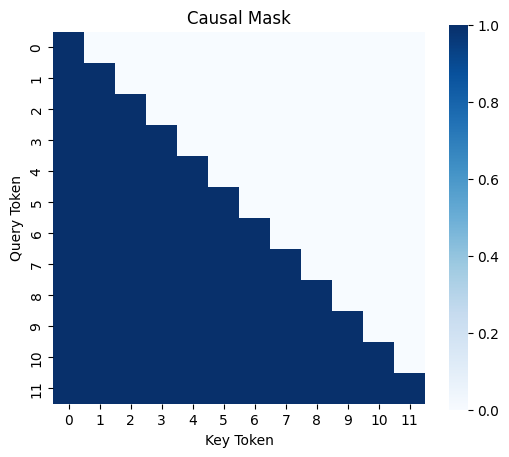

In [ ]:
def create_causal_mask(seq_len, device):

    mask = torch.tril(
        torch.ones(
            seq_len,
            seq_len,
            device=device
        )
    )

    # Shape : [1, 1, seq_len, seq_len]
    return mask.unsqueeze(0).unsqueeze(0)


mask = create_causal_mask(
    max_len - 1,
    device
)

print(mask.shape)

plt.figure(figsize=(6, 5))

sns.heatmap(
    mask[0, 0].cpu(),
    cmap="Blues",
    square=True
)

plt.title("Causal Mask")
plt.xlabel("Key Token")
plt.ylabel("Query Token")

plt.show()



In [ ]:
class MLPBlock(nn.Module):

    def __init__(self, d_model, d_ff):
        super().__init__()

        self.fc1 = nn.Linear(
            d_model,
            d_ff
        )

        self.fc2 = nn.Linear(
            d_ff,
            d_model
        )

        self.activation = nn.GELU()

    def forward(self, x):

        x = self.fc1(x)

        x = self.activation(x)

        x = self.fc2(x)

        return x


In [ ]:
class TransformerBlock(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        self.attention = MultiHeadSelfAttention(
            d_model,
            num_heads
        )

        self.mlp = MLPBlock(
            d_model,
            d_ff
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):

        # -----------------------------
        # Self-Attention
        # -----------------------------

        attention_output, attention_weights = self.attention(
            x,
            mask
        )

        # Residual + LayerNorm
        x = self.norm1(
            x + self.dropout(attention_output)
        )

        # -----------------------------
        # MLP
        # -----------------------------

        mlp_output = self.mlp(x)

        # Residual + LayerNorm
        x = self.norm2(
            x + self.dropout(mlp_output)
        )

        return x, attention_weights


In [ ]:
class MiniTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=64,
        num_heads=4,
        d_ff=128,
        num_layers=2,
        max_len=50,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        # Embedding
        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        # Positional Encoding
        self.position = PositionalEncoding(
            d_model,
            max_len
        )

        # Transformer Blocks
        self.layers = nn.ModuleList([
            TransformerBlock(
                d_model,
                num_heads,
                d_ff,
                dropout
            )
            for _ in range(num_layers)
        ])

        # Couche finale
        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, x):

        # Embedding
        x = self.embedding(x)

        # Scaling des embeddings
        x = x * math.sqrt(self.d_model)

        # Position
        x = self.position(x)

        # Masque causal
        mask = create_causal_mask(
            x.size(1),
            x.device
        )

        attention_maps = []

        # Transformer layers
        for layer in self.layers:

            x, attention = layer(
                x,
                mask
            )

            attention_maps.append(attention)

        # Prédiction
        logits = self.output_layer(x)

        return logits, attention_maps


In [ ]:
D_MODEL = 64
NUM_HEADS = 4
D_FF = 128
NUM_LAYERS = 3

model = MiniTransformer(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    max_len=max_len
).to(device)

num_params = sum(
    p.numel()
    for p in model.parameters()
)
print(model)

print(f"\n---\nNombre de paramètres : {num_params:,}")
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Paramètres totaux      : {total_params:,}")
print(f"Paramètres entraînables: {trainable_params:,}")



MiniTransformer(
  (embedding): Embedding(368, 64)
  (position): PositionalEncoding()
  (layers): ModuleList(
    (0-2): 3 x TransformerBlock(
      (attention): MultiHeadSelfAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (mlp): MLPBlock(
        (fc1): Linear(in_features=64, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=64, bias=True)
        (activation): GELU(approximate='none')
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (output_layer): Linear(in_features=64, out_features=368, bias=True)
)

---
Nombre de paramètres : 147,888
Paramètres totaux      : 147,

In [ ]:
inputs_device = inputs.to(device)
targets_device = targets.to(device)

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.003
)


In [ ]:
EPOCHS = 250

losses = []

model.train()

for epoch in range(EPOCHS):

    optimizer.zero_grad()

    logits, attention_maps = model(
        inputs_device
    )

    # logits :
    # [batch, seq_len, vocab_size]

    # targets :
    # [batch, seq_len]

    loss = criterion(
        logits.reshape(-1, vocab_size),
        targets_device.reshape(-1)
    )

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch+1:3d}/{EPOCHS} "
            f"- Loss: {loss.item():.4f}"
        )


Epoch  50/250 - Loss: 1.7601
Epoch 100/250 - Loss: 1.0230
Epoch 150/250 - Loss: 0.9240
Epoch 200/250 - Loss: 0.9076
Epoch 250/250 - Loss: 0.9018


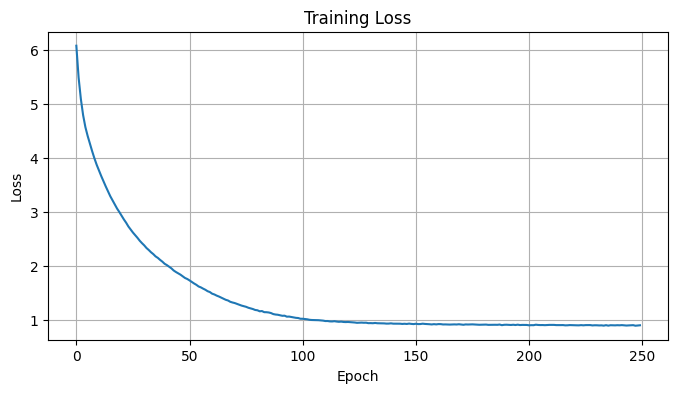

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()

plt.show()


---

## Result & Interpretation

We are gonna see what our model has trained, and how it works.
- First, we will test its performance on prediction and text generation.
- Secondly, we will analyze its internal representation to better understand how it works.

In [ ]:
def predict_next_token(model, text):

    model.eval()

    token_ids = encode(text)

    # On enlève EOS s'il existe
    if token_ids[-1] == word_to_id["<EOS>"]:
        token_ids = token_ids[:-1]

    x = torch.tensor(
        [token_ids],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        logits, attention_maps = model(x)

        # Dernière position
        next_token_logits = logits[0, -1]

        probabilities = F.softmax(
            next_token_logits,
            dim=-1
        )

        next_token_id = torch.argmax(
            probabilities
        ).item()

    return (
        id_to_word[next_token_id],
        probabilities,
        attention_maps
    )


In [ ]:
test_phrases = [
    "i",
    "she",
    "the boy reads",
    "the red",
    "the book is on the",
    "the dog does not",
    "the dog is hungry so it",
    "the dog chases the",
    "the boy sleeps at",
    "the boy reads a book while the dog",
    "the man goes to the bank to get some",
    "the teacher helps the",
    "where is the",
    "the boy is hungry so he",
    "the mountain is higher than the",
]


for text in test_phrases:

    prediction, probabilities, _ = predict_next_token(
        model,
        text
    )

    top_probs, top_ids = torch.topk(probabilities, 5)

    print("\n" + "-" * 50)
    print(f'"{text}" → "{prediction}"')

    for prob, token_id in zip(top_probs, top_ids):
        print(
            f"  {id_to_word[token_id.item()]:<12}"
            f"{prob.item() * 100:6.2f}%"
        )


--------------------------------------------------
"i" → "am"
  am           51.07%
  eat          48.24%
  are           0.19%
  know          0.06%
  like          0.04%

--------------------------------------------------
"she" → "eats"
  eats         40.57%
  is           37.99%
  does         20.98%
  sleeps        0.12%
  gives         0.02%

--------------------------------------------------
"the boy reads" → "a"
  a            99.42%
  an            0.18%
  the           0.10%
  some          0.10%
  tree          0.07%

--------------------------------------------------
"the red" → "car"
  car          56.52%
  boat         23.17%
  bird         18.35%
  bag           0.42%
  lamp          0.34%

--------------------------------------------------
"the book is on the" → "table"
  table        98.60%
  desk          0.40%
  sofa          0.28%
  to            0.10%
  lake          0.09%

--------------------------------------------------
"the dog does not" → "like"
  like       

In [ ]:
def generate_text(
    model,
    prompt,
    max_new_tokens=20
):

    model.eval()

    token_ids = encode(prompt)

    # Retirer EOS
    if token_ids[-1] == word_to_id["<EOS>"]:
        token_ids = token_ids[:-1]

    for _ in range(max_new_tokens):

        x = torch.tensor(
            [token_ids],
            dtype=torch.long
        ).to(device)

        with torch.no_grad():

            logits, _ = model(x)

            next_token_logits = logits[0, -1]

            probabilities = F.softmax(
                next_token_logits,
                dim=-1
            )

            next_token_id = torch.multinomial(
                probabilities,
                1
            ).item()


        token_ids.append(next_token_id)

        if next_token_id == word_to_id["<EOS>"]:
            break

    tokens = decode(token_ids)

    # Retirer les tokens spéciaux
    tokens = [
        token for token in tokens
        if token not in ["<BOS>", "<EOS>", "<PAD>"]
    ]

    return " ".join(tokens)


In [ ]:
prompts = [
    "i",
    "the girl",
    "the dog does not",
    "where",
    "while",
]

for prompt in prompts:

    print("-" * 50)
    print("Input   :", prompt)

    outputs = set()
    attempts = 0
    max_attempts = 100

    while len(outputs) < 5 and attempts < max_attempts:

        generated = generate_text(
            model,
            prompt,
            max_new_tokens=10
        )

        outputs.add(generated)
        attempts += 1

    for i, generated in enumerate(outputs, 1):
        print("Output", str(i) + ":", generated)




--------------------------------------------------
Input   : i
Output 1: i eat a banana
Output 2: i am a nurse
Output 3: i am an engineer
Output 4: i eat an apple
Output 5: i eat a mango
--------------------------------------------------
Input   : the girl
Output 1: the girl waits for her mother
Output 2: the girl sees a bat inside the cave
Output 3: the girl carries the bag
Output 4: the girl takes the blue book from the table
Output 5: the girl is tired so she sits on the sofa
--------------------------------------------------
Input   : the dog does not
Output 1: the dog does not like the rain
Output 2: the dog does not want the rain
Output 3: the dog does not eat vegetables
Output 4: the dog does not like loud noises
Output 5: the dog does not like cold weather
--------------------------------------------------
Input   : where
Output 1: where is the book
Output 2: where is the cat
Output 3: where is the lamp
Output 4: where is the boat
Output 5: where is the phone
------------------

In [ ]:
def plot_attention_maps(
    model,
    text,
    layer_idx=0
):

    model.eval()

    token_ids = encode(text)

    # Retirer EOS pour avoir les tokens visibles
    if token_ids[-1] == word_to_id["<EOS>"]:
        token_ids = token_ids[:-1]

    tokens = decode(token_ids)

    x = torch.tensor(
        [token_ids],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        _, attention_maps = model(x)

    # Attention :
    # [batch, heads, seq_len, seq_len]

    attention = attention_maps[layer_idx][0]

    num_heads = attention.shape[0]

    fig, axes = plt.subplots(
        1,
        num_heads,
        figsize=(5 * num_heads, 5)
    )

    if num_heads == 1:
        axes = [axes]

    for head in range(num_heads):

        attn = attention[
            head
        ].detach().cpu().numpy()

        sns.heatmap(
            attn,
            ax=axes[head],
            cmap="Blues",
            vmin=0,
            vmax=1,
            annot=True,
            fmt=".2f",
            xticklabels=tokens,
            yticklabels=tokens,
            square=True
        )

        axes[head].set_title(
            f"Layer {layer_idx + 1} - Head {head + 1}"
        )

        axes[head].set_xlabel(
            "Key Token"
        )

        axes[head].set_ylabel(
            "Query Token"
        )

    plt.tight_layout()
    plt.show()


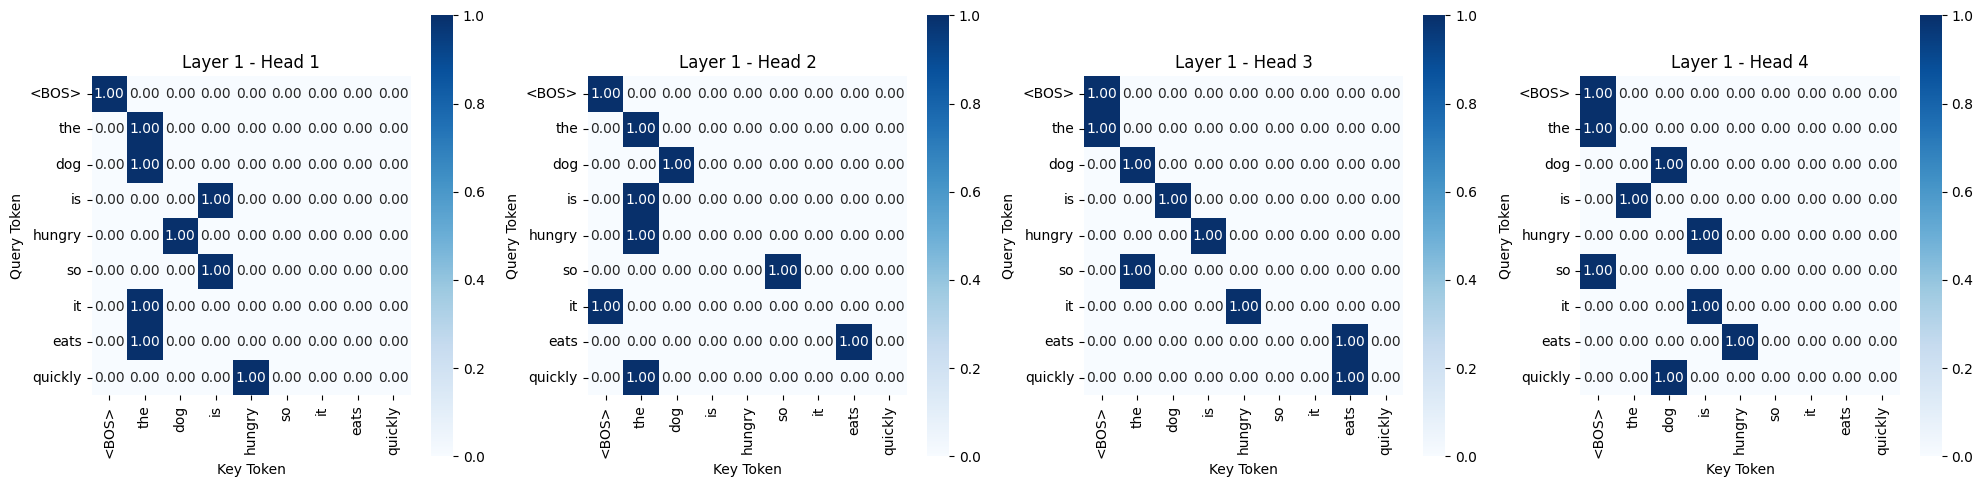

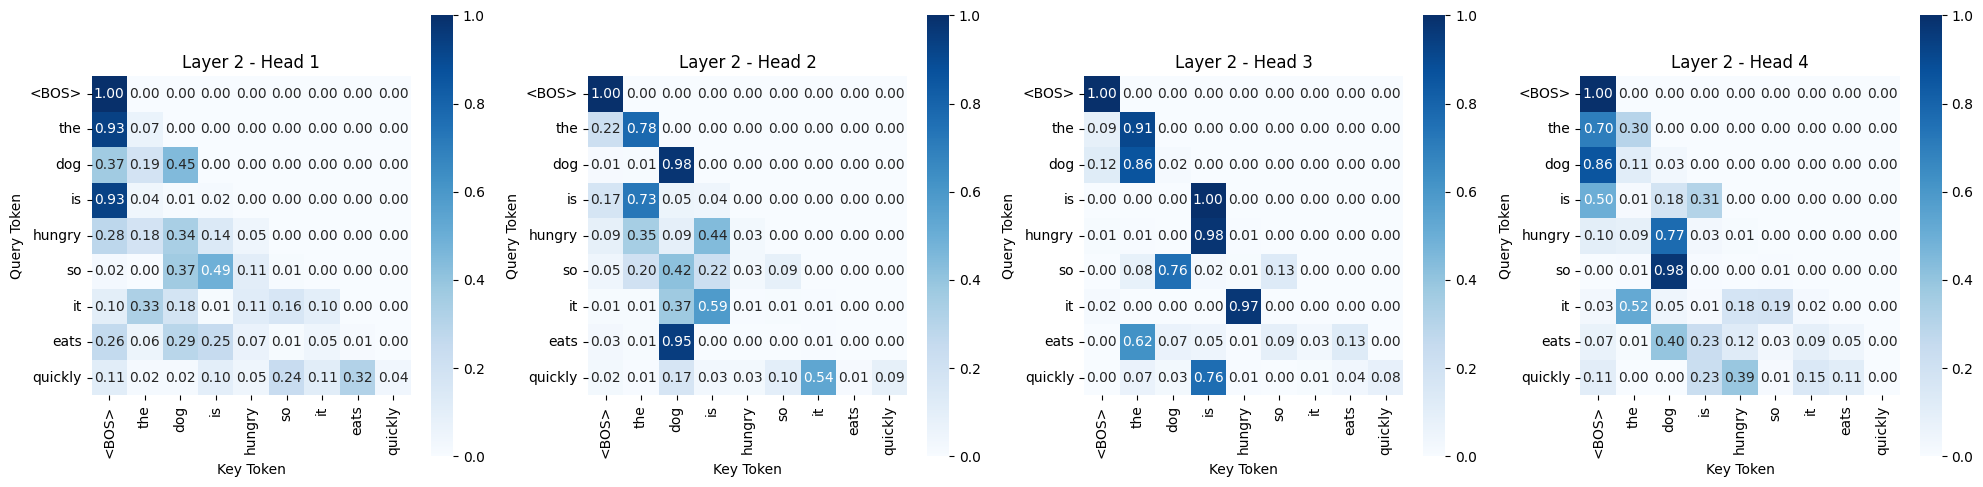

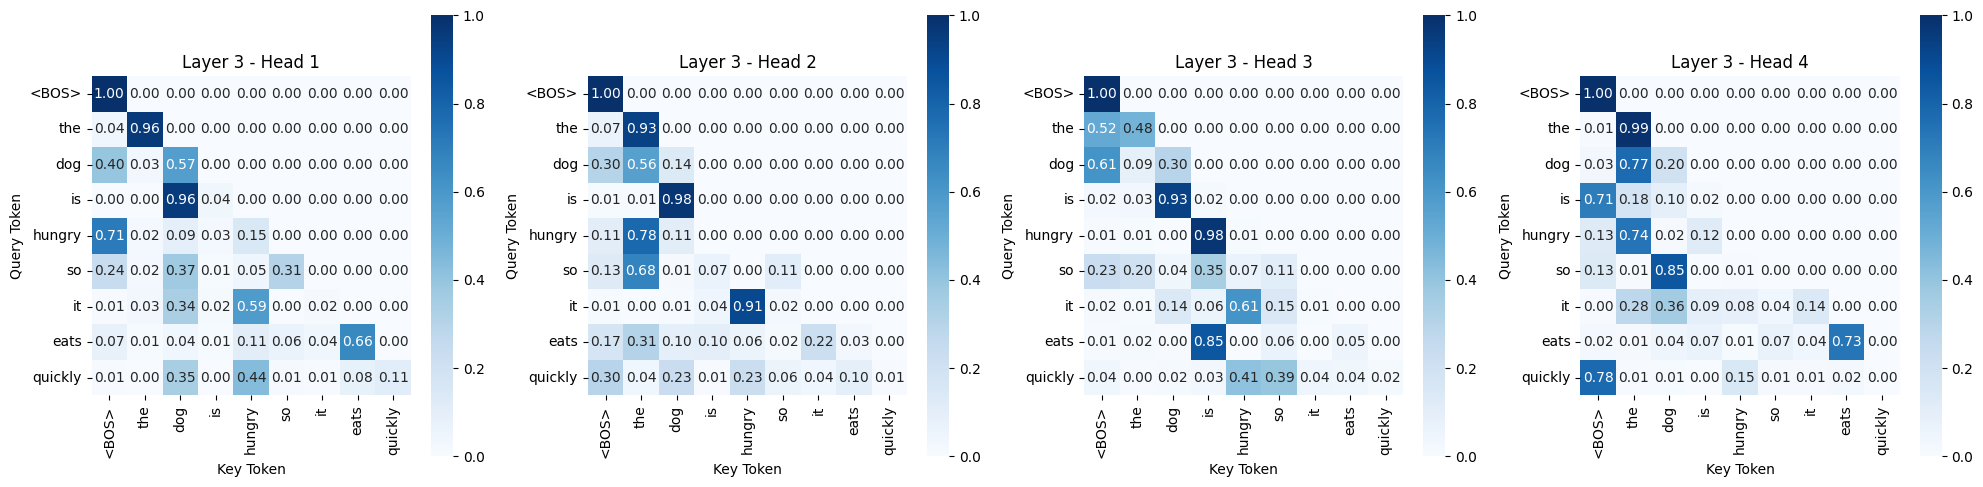

In [ ]:
test_text = "the dog is hungry so it eats quickly" #alt: "the boy reads a book while the dog sleeps beside him"

plot_attention_maps(
    model,
    test_text,
    layer_idx=0
)
plot_attention_maps(
    model,
    test_text,
    layer_idx=1
)
plot_attention_maps(
    model,
    test_text,
    layer_idx=2
)

In [ ]:
# YOU NEED WEBGL TO RUN THIS CELL PROPERLY, I RECOMMEND USING GOOGLE COLAB OR JUPYTER NOTEBOOK WITH PLOTLY INSTALLED

import plotly.graph_objects as go

with torch.no_grad():
    embeddings = model.embedding.weight.detach().cpu()

# Center the data
embeddings_centered = embeddings - embeddings.mean(dim=0)

# Full SVD
U, S, Vh = torch.linalg.svd(
    embeddings_centered,
    full_matrices=False
)

explained_var_ratio = (S ** 2) / (S ** 2).sum()

print("PC1:", explained_var_ratio[0].item())
print("PC2:", explained_var_ratio[1].item())
print("PC3:", explained_var_ratio[2].item())
print("Cumulative:", explained_var_ratio[:3].sum().item())


# Project onto the first 3 principal components
embeddings_3d = embeddings_centered @ Vh[:, :3]

explained_var = (S[:3] ** 2) / (S ** 2).sum()

words = [id_to_word[i] for i in range(vocab_size)]

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=embeddings_3d[:, 0],
            y=embeddings_3d[:, 1],
            z=embeddings_3d[:, 2],
            mode="markers+text",
            text=words,
            textposition="top center",
            textfont=dict(size=9),
            marker=dict(
                size=5,
                color=embeddings_3d[:, 2],
                colorscale="Viridis",
                opacity=0.8
            ),
            hovertemplate="<b>%{text}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
        )
    ]
)

fig.update_layout(
    title=(
        f"3D PCA of Token Embeddings "
        f"(PC1: {explained_var[0]*100:.1f}%, "
        f"PC2: {explained_var[1]*100:.1f}%, "
        f"PC3: {explained_var[2]*100:.1f}%)"
    ),
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    width=900,
    height=800,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

PC1: 0.030913474038243294
PC2: 0.028758643195033073
PC3: 0.028181403875350952
Cumulative: 0.08785352110862732


In [ ]:
import plotly.graph_objects as go

def get_before_after_representations(model, text):

    model.eval()

    token_ids = encode(text)

    if token_ids[-1] == word_to_id["<EOS>"]:
        token_ids = token_ids[:-1]

    tokens = decode(token_ids)

    x = torch.tensor(
        [token_ids],
        dtype=torch.long
    ).to(device)

    representations = {}

    def hook_before(module, input, output):
        representations["before"] = output.detach()

    def hook_after(module, input, output):
        representations["after"] = input[0].detach()

    handle_before = model.position.register_forward_hook(hook_before)
    handle_after = model.output_layer.register_forward_hook(hook_after)

    with torch.no_grad():
        model(x)

    handle_before.remove()
    handle_after.remove()

    before = representations["before"][0].cpu()  # [seq_len, d_model]
    after = representations["after"][0].cpu()    # [seq_len, d_model]

    return tokens, before, after


def plot_pca_3d(tokens, reps, title, marker_color="royalblue"):

    reps_centered = reps - reps.mean(dim=0)

    U, S, Vh = torch.linalg.svd(
        reps_centered,
        full_matrices=False
    )

    principal_components = Vh[:3, :].T  # [d_model, 3]

    reps_3d = reps_centered @ principal_components

    explained_var = (S[:3] ** 2) / (S ** 2).sum()

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=reps_3d[:, 0],
                y=reps_3d[:, 1],
                z=reps_3d[:, 2],
                mode="markers+text+lines",
                text=tokens,
                textposition="top center",
                textfont=dict(size=11),
                line=dict(color="gray", width=2),
                marker=dict(
                    size=6,
                    color=list(range(len(tokens))),
                    colorscale="Plasma",
                    colorbar=dict(title="Position"),
                    opacity=0.9
                ),
                hovertemplate="<b>%{text}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
            )
        ]
    )

    fig.update_layout(
        title=(
            f"{title}<br>"
            f"(PC1: {explained_var[0]*100:.1f}%, "
            f"PC2: {explained_var[1]*100:.1f}%, "
            f"PC3: {explained_var[2]*100:.1f}%)"
        ),
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3"
        ),
        width=900,
        height=800,
        margin=dict(l=0, r=0, b=0, t=80)
    )

    fig.show()


text = "the dog is hungry so it eats quickly"

tokens, before, after = get_before_after_representations(model, text)

plot_pca_3d(tokens, before, f'BEFORE processing: "{text}"')
plot_pca_3d(tokens, after, f'AFTER processing: "{text}"')